# 11 — Discretisation

**The concept:** turning a number into a symbolic fact — `mass_kg = 880` into `mass_band = "heavy"`
— needs a **threshold**. That threshold is a *hypothesis*, it silently decides the answer, and in
most code it lives in a helper function where nobody reviews it.

So it is not glue code. It is a declared object the pipeline carries and `validate()` can read.

In [1]:
from smartmdao import Pipeline, Bands, Discretisation, validate, explain, analyze

pipeline = Pipeline(
    discretisation=Discretisation(
        mass_band=Bands("mass_kg", edges=[800, 1200],
                        names=["light", "medium", "heavy"]),
    ),
)

@pipeline.step(outputs=["mass_kg"])
def size_airframe(span_m: float) -> float:
    return 120.0 * span_m

@pipeline.step(outputs=["margin"])
def pick_margin(mass_band: str) -> float:
    return {"light": 0.05, "medium": 0.10, "heavy": 0.20}[mass_band]

result = pipeline.run(span_m=7.0)
print(f"span 7.0 m -> {result['mass_kg']} kg -> {result['mass_band']!r} -> margin {result['margin']:.0%}")

span 7.0 m -> 840.0 kg -> 'medium' -> margin 10%


## A band is an ordinary step

The band is not applied "around the outside". It is registered as a real `Step`, so the solver
orders it like anything else and every existing check sees it — which is why this feature needed no
special cases in the analysis layer.

In [2]:
print("execution order:", analyze(pipeline, inputs=["span_m"]).execution_order)

execution order: ('size_airframe', 'discretise_mass_band', 'pick_margin')


And it appears in the diagram as a discipline like any other —
`discretise_mass_band`, sitting between the step that produces `mass_kg` and the step that consumes
`mass_band`:

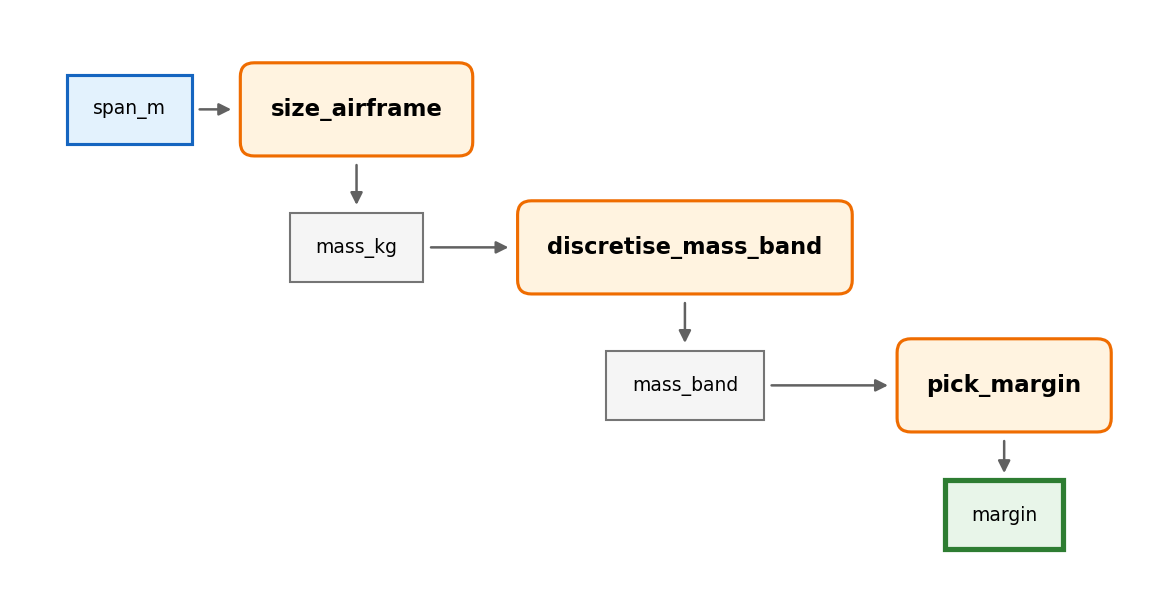

In [3]:
import matplotlib
matplotlib.use("Agg", force=True)

import pathlib, tempfile
from IPython.display import Image

_gallery = pathlib.Path(tempfile.mkdtemp())

def show(pipeline, inputs, name):
    """Render a pipeline to PNG and display it inline. See notebook 02."""
    path = _gallery / f"{name}.png"
    pipeline.visualize(inputs=inputs, output_path=str(path), view=False)
    return Image(filename=str(path))

show(pipeline, ["span_m"], "banded")

## The boundary value has a declared side

`closed="left"` (the default) makes each band `[lower, upper)`, so an exact 800.0 is `"medium"`.
Whether 800 is heavy is exactly the kind of default that changes an answer quietly, so it is a
**field**, not a convention you discover by experiment.

In [4]:
left = Bands("mass_kg", edges=[800], names=["light", "heavy"])
right = Bands("mass_kg", edges=[800], names=["light", "heavy"], closed="right")

print("closed='left' :", left.describe())
print("closed='right':", right.describe())
print()
for value in (799.9, 800.0, 800.1):
    print(f"  {value:7} -> left={left.classify(value):6} right={right.classify(value)}")

closed='left' : mass_kg -> light=(-inf, 800); heavy=[800, +inf)
closed='right': mass_kg -> light=(-inf, 800]; heavy=(800, +inf)

    799.9 -> left=light  right=light
    800.0 -> left=heavy  right=light
    800.1 -> left=heavy  right=heavy


Note where they agree. Away from the boundary the two conventions are identical, which is
precisely why the disagreement is easy to miss.

## Incoherent declarations are refused at construction

A typo has no defensible reading, so there is no informed decision to hand back — it raises
immediately rather than becoming a finding.

In [5]:
from smartmdao import DiscretisationError

attempts = [
    ("two names for three intervals", dict(edges=[800, 1200], names=["light", "heavy"])),
    ("edges that do not ascend",      dict(edges=[1200, 800], names=["a", "b", "c"])),
    ("an unreachable band",           dict(edges=[800, 800], names=["a", "b", "c"])),
    ("a NaN edge",                    dict(edges=[float("nan")], names=["a", "b"])),
]

for description, kwargs in attempts:
    try:
        Bands("mass_kg", **kwargs)
    except DiscretisationError as error:
        print(f"{description:32} {str(error).split('.')[0]}.")

two names for three intervals    Bands for 'mass_kg' needs one more name than edges: 2 edge(s) cut the line into 3 intervals, but 2 name(s) were given.
edges that do not ascend         Bands for 'mass_kg' has edges that do not strictly ascend: [1200, 800].
an unreachable band              Bands for 'mass_kg' has edges that do not strictly ascend: [800, 800].
a NaN edge                       Bands for 'mass_kg' has a NaN edge, which no value can be compared against.


## What `validate()` reports

Judgement calls are reported rather than raised.

In [6]:
orphan = Pipeline(
    discretisation=Discretisation(
        mass_band=Bands("mass_kg", edges=[800], names=["light", "heavy"]),
    ),
)

@orphan.step(outputs=["mass_kg"])
def size(span_m: float) -> float:
    return 120.0 * span_m

for finding in validate(orphan, inputs=["span_m"]):
    print(f"[{finding.severity.upper()}] {finding.code}")
    print(f"   {finding.message}")

[INFO] discretisation-unused
   'mass_band' is discretised from 'mass_kg' and no step inside the pipeline consumes it. That is a mistake if you expected it to be wired in, and perfectly correct if you read it from the result and act on it outside - which is what the recommended topology in docs/design/002 does. Both look identical from here, which is why this is information rather than a warning.


Note the severity: **info, not warning**. A band nothing consumes is either an orphan *or* a
value the caller reads from the result and acts on outside the pipeline — which is the recommended
topology. The two are indistinguishable from here, and warning about it would fire on the pattern
the project recommends.

In [7]:
mistyped = Pipeline(
    discretisation=Discretisation(
        mass_band=Bands("label", edges=[800], names=["light", "heavy"]),
    ),
)

@mistyped.step(outputs=["label"])
def make_label() -> str:
    return "wing"

@mistyped.step(outputs=["cost"])
def price(mass_band: str) -> float:
    return 1.0

for finding in validate(mistyped):
    print(f"[{finding.code}] {finding.message}")

[discretisation-non-numeric] 'label' is declared as str by 'make_label', but bands for 'mass_band' compare it against numeric edges. Classification will raise at run time. The band's own parameter is left unannotated on purpose, so the type edges cannot catch this.


## `explain()` states the thresholds

Which is the point of declaring them — a reviewer sees the numbers without reading the source.

In [8]:
for line in explain(pipeline, inputs=["span_m"]).splitlines():
    if "Discretisation" in line or "mass_kg ->" in line or "edge values" in line:
        print(line)

Discretisation (1):
  mass_band: mass_kg -> light=(-inf, 800); medium=[800, 1200); heavy=[1200, +inf)
     edge values fall in the band above (closed='left')


## Two traps worth knowing

**A threshold inside a feedback loop can give the loop more than one answer.** Seeded light it
settles light; seeded heavy it settles heavy. Both converge, both are self-consistent, and the
initial guess alone decides which you get.

In [9]:
from smartmdao import HybridSolver

def bistable():
    loop = Pipeline(
        solver=HybridSolver(),
        discretisation=Discretisation(
            mass_band=Bands("total_mass_kg", edges=[500], names=["light", "heavy"]),
        ),
    )

    @loop.step(outputs=["structure_mass_kg"])
    def size_structure(mass_band: str) -> float:
        return 200.0 if mass_band == "light" else 260.0

    @loop.step(outputs=["total_mass_kg"])
    def sum_masses(structure_mass_kg: float, payload_kg: float) -> float:
        return structure_mass_kg + payload_kg

    return loop

for seed in (400.0, 900.0):
    out = bistable().run(payload_kg=250.0, total_mass_kg=seed)
    report = out["convergence_reports"][0]
    print(f"seed {seed:6.1f} -> band {out['mass_band']:6} "
          f"total {out['total_mass_kg']:6.1f}  status {report.status}")

seed  400.0 -> band light  total  450.0  status converged
seed  900.0 -> band heavy  total  510.0  status converged


`validate()` reports the risk statically, so you are told before you run it.

In [10]:
for finding in validate(bistable(), inputs=["payload_kg"]):
    if finding.code == "discretisation-in-cycle":
        print(f"[{finding.code}] {finding.message}")

[discretisation-in-cycle] 'mass_band' is derived from a threshold inside the loop discretise_mass_band -> size_structure -> sum_masses. A value crossing an edge mid-solve changes the band, which changes the result, which can move the value back - so this loop may settle in more than one place, each converged and self-consistent, chosen by the initial guess alone. Nothing reports which one you got.


**And the band's step name takes part in the alphabetical seeding rule.** The synthetic step is
called `discretise_<band>`, which sorts before most verbs — so it usually runs first and *its* input
is the one needing a seed. Ask `analyze()`.

In [11]:
analysis = analyze(bistable(), inputs=["payload_kg"])
print("cycle:", analysis.cycles[0].steps)
print("needs a seed for:", [g.variable for g in analysis.initial_guesses_required])

cycle: ('discretise_mass_band', 'size_structure', 'sum_masses')
needs a seed for: ['total_mass_kg']


---

**Next:** [12 — Rule-backed disciplines](12-rule-backed-disciplines.ipynb), which is what the
symbolic fact was for.